In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL
import warnings
warnings.filterwarnings('ignore')

# ── Load credentials from .env file ─────────────────
load_dotenv(r"C:\Users\Administrator\Desktop\kenya_road_safety_project\.env")

# ── Plot style ───────────────────────────────────────
plt.rcParams['figure.dpi']       = 120
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

# ── Paths ────────────────────────────────────────────
BASE_DIR   = r"C:\Users\Administrator\Desktop\kenya_road_safety_project"
CLEAN_DATA = os.path.join(BASE_DIR, "data", "cleaned", "accidents_clean.csv")
VISUALS    = os.path.join(BASE_DIR, "visuals")
os.makedirs(VISUALS, exist_ok=True)

# ── Database connection ──────────────────────────────
connection_url = URL.create(
    drivername = "postgresql+psycopg2",
    username   = os.getenv("DB_USER"),
    password   = os.getenv("DB_PASSWORD"),
    host       = os.getenv("DB_HOST"),
    port       = int(os.getenv("DB_PORT")),
    database   = os.getenv("DB_NAME")
)
engine = create_engine(connection_url)

# ── Load cleaned data ────────────────────────────────
df = pd.read_csv(CLEAN_DATA)

print("Data loaded successfully")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())


Data loaded successfully
Shape: (1119, 20)
Columns: ['time', 'base', 'county', 'road', 'place', 'mv_involved', 'accident_details', 'victim_name', 'gender', 'age', 'cause_code', 'victim_type', 'num_victims', 'date', 'hour', 'time_of_day', 'age_group', 'victim_category', 'is_fatal', 'gender_clean']


In [3]:
# ── Load cleaned data ────────────────────────────────
df = pd.read_csv(CLEAN_DATA)

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

print("Data loaded successfully")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Data loaded successfully
Shape: (1119, 20)
Columns: ['time', 'base', 'county', 'road', 'place', 'mv_involved', 'accident_details', 'victim_name', 'gender', 'age', 'cause_code', 'victim_type', 'num_victims', 'date', 'hour', 'time_of_day', 'age_group', 'victim_category', 'is_fatal', 'gender_clean']


In [4]:
print("="*55)
print("KENYA ROAD ACCIDENT DATASET — OVERVIEW")
print("="*55)
print(f"Total accident records : {len(df)}")
print(f"Total columns          : {len(df.columns)}")

# Handle date safely
valid_dates = df['date'].dropna()
if len(valid_dates) > 0:
    print(f"Date range             : {valid_dates.min().date()} "
          f"to {valid_dates.max().date()}")
else:
    print(f"Date range             : No valid dates found")

print(f"Unique counties        : {df['county'].nunique()}")
print(f"Unique roads           : {df['road'].nunique()}")
print(f"Fatal accidents        : {df['is_fatal'].sum()}")
print(f"Fatal rate             : "
      f"{df['is_fatal'].mean()*100:.1f}%")
print(f"\nTime of day breakdown:")
print(df['time_of_day'].value_counts())
print(f"\nVictim category breakdown:")
print(df['victim_category'].value_counts())

KENYA ROAD ACCIDENT DATASET — OVERVIEW
Total accident records : 1119
Total columns          : 20
Date range             : 2016-04-13 to 2017-10-31
Unique counties        : 42
Unique roads           : 715
Fatal accidents        : 40
Fatal rate             : 3.6%

Time of day breakdown:
time_of_day
Evening      341
Night        292
Afternoon    231
Morning      230
Unknown       25
Name: count, dtype: int64

Victim category breakdown:
victim_category
Pedestrian      455
Motorcyclist    250
Passenger       246
Driver          135
Cyclist          29
Other             2
Unknown           2
Name: count, dtype: int64


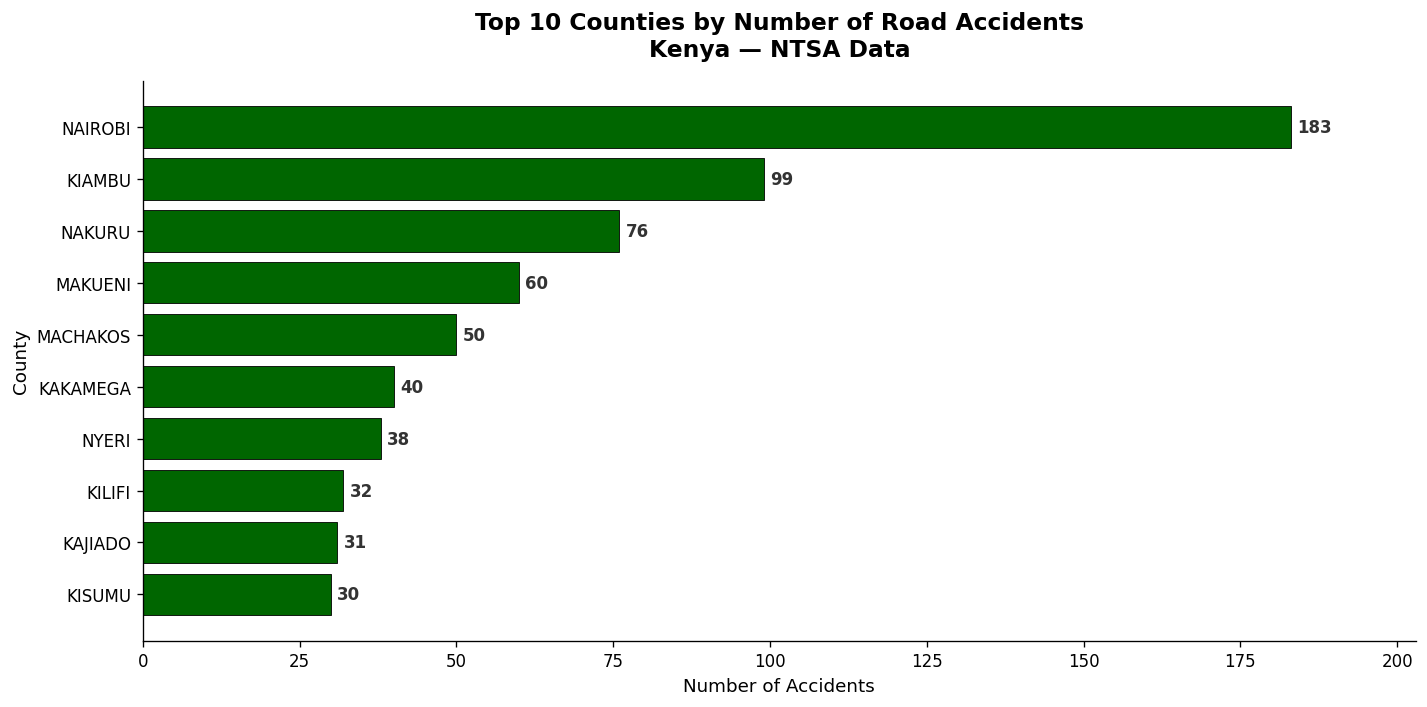

Chart 1 saved


In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

county_counts = (
    df['county']
    .value_counts()
    .head(10)
)

bars = ax.barh(
    county_counts.index[::-1],
    county_counts.values[::-1],
    color='#006600', edgecolor='black', linewidth=0.5
)

# Add value labels on bars
for bar, val in zip(bars, county_counts.values[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() +
            bar.get_height()/2,
            str(val), va='center', fontsize=10,
            fontweight='bold', color='#333333')

ax.set_title('Top 10 Counties by Number of Road Accidents\n'
             'Kenya — NTSA Data',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Accidents', fontsize=11)
ax.set_ylabel('County', fontsize=11)
ax.set_xlim(0, county_counts.max() + 20)

plt.tight_layout()
plt.savefig(os.path.join(VISUALS, 'chart1_accidents_by_county.png'),
            bbox_inches='tight')
plt.show()
print("Chart 1 saved")

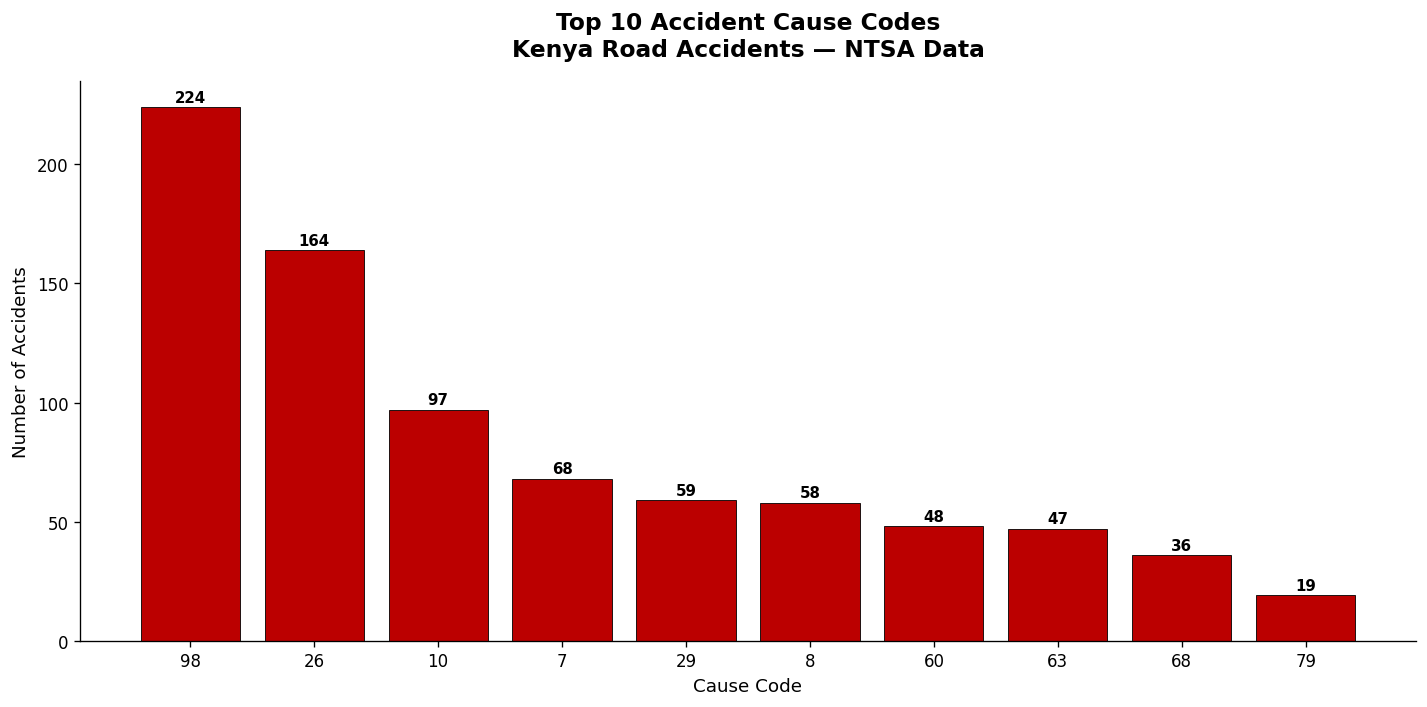

Chart 2 saved


In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

cause_counts = (
    df['cause_code']
    .value_counts()
    .head(10)
)

bars = ax.bar(
    cause_counts.index.astype(str),
    cause_counts.values,
    color='#BB0000', edgecolor='black', linewidth=0.5
)

# Add value labels on top of bars
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            str(int(bar.get_height())),
            ha='center', va='bottom',
            fontsize=9, fontweight='bold')

ax.set_title('Top 10 Accident Cause Codes\n'
             'Kenya Road Accidents — NTSA Data',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Cause Code', fontsize=11)
ax.set_ylabel('Number of Accidents', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(VISUALS, 'chart2_accident_causes.png'),
            bbox_inches='tight')
plt.show()
print("Chart 2 saved")

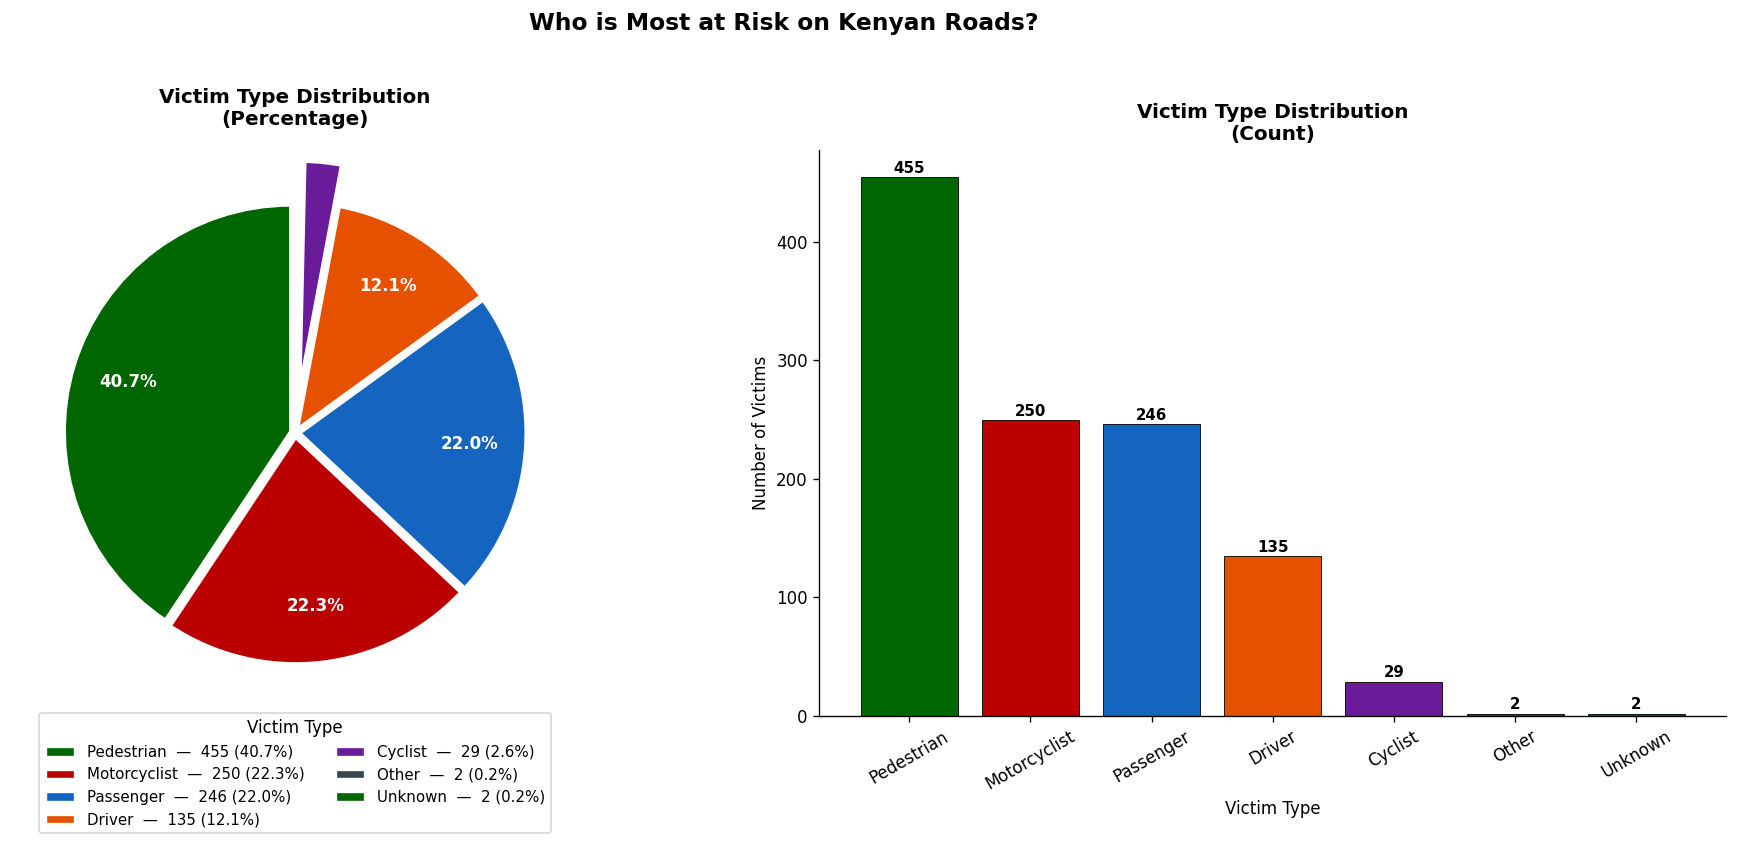

Chart 3 saved


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

victim_counts = df['victim_category'].value_counts()

colors = ['#006600','#BB0000','#1565C0',
          '#E65100','#6A1B9A','#37474F']

# ── Custom autopct — only show % if slice is big enough
def make_autopct(values):
    def autopct(pct):
        if pct > 4:           # only show if slice > 4%
            return f'{pct:.1f}%'
        return ''             # hide % for tiny slices
    return autopct

explode = []
for val in victim_counts.values:
    if val / victim_counts.sum() < 0.05:
        explode.append(0.2)   # push small slices further out
    else:
        explode.append(0.02)

wedges, texts, autotexts = ax1.pie(
    victim_counts.values,
    labels=None,
    autopct=make_autopct(victim_counts.values),
    colors=colors,
    startangle=90,
    explode=explode,
    pctdistance=0.75,
    wedgeprops={'edgecolor':'white', 'linewidth':2}
)

for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
    at.set_color('white')

# ── Add legend with counts and percentages ───────────
total = victim_counts.sum()
legend_labels = [
    f"{label}  —  {val} ({val/total*100:.1f}%)"
    for label, val in zip(
        victim_counts.index,
        victim_counts.values
    )
]

ax1.legend(
    wedges,
    legend_labels,
    title="Victim Type",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.22),
    fontsize=9,
    ncol=2,
    frameon=True
)

ax1.set_title('Victim Type Distribution\n(Percentage)',
              fontsize=12, fontweight='bold', pad=15)

# ── Bar chart ────────────────────────────────────────
bars = ax2.bar(
    victim_counts.index,
    victim_counts.values,
    color=colors[:len(victim_counts)],
    edgecolor='black', linewidth=0.5
)
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             str(int(bar.get_height())),
             ha='center', va='bottom',
             fontsize=9, fontweight='bold')

ax2.set_title('Victim Type Distribution\n(Count)',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Victim Type', fontsize=10)
ax2.set_ylabel('Number of Victims', fontsize=10)
ax2.tick_params(axis='x', rotation=30)

plt.suptitle('Who is Most at Risk on Kenyan Roads?',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(VISUALS, 'chart3_victim_types.png'),
            bbox_inches='tight')
plt.show()
print("Chart 3 saved")


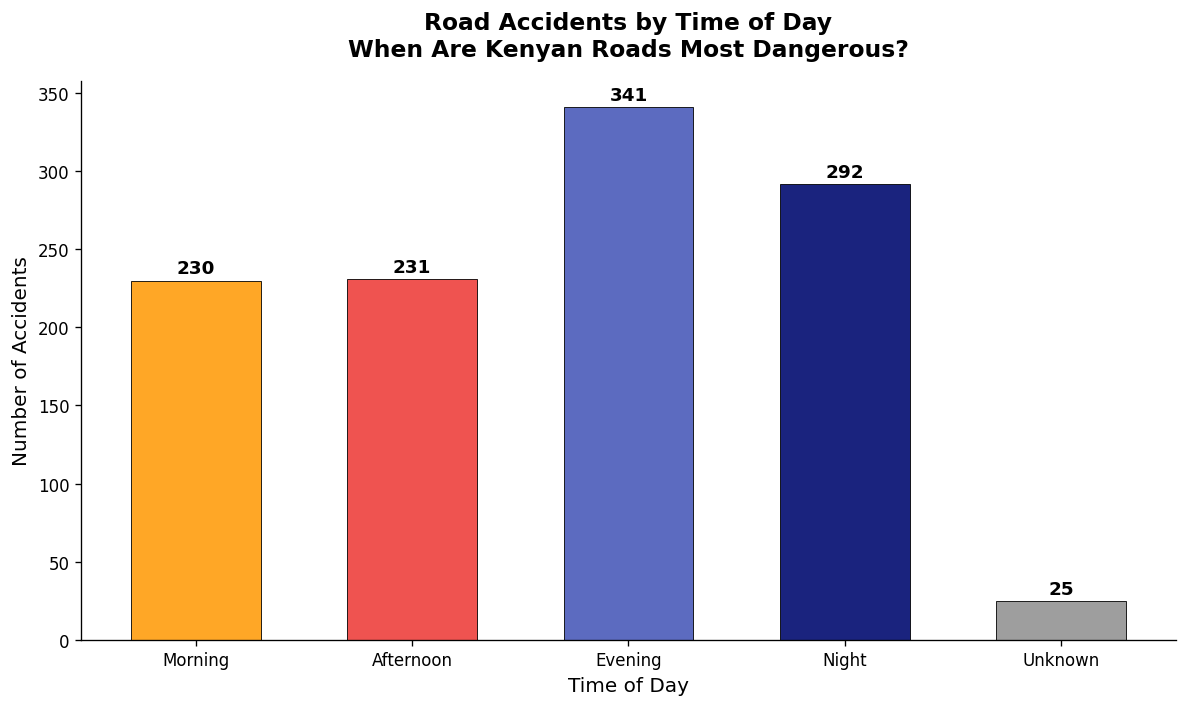

Chart 4 saved


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))

time_order  = ['Morning', 'Afternoon', 'Evening',
               'Night', 'Unknown']
time_counts = df['time_of_day'].value_counts()
time_counts = time_counts.reindex(
    [t for t in time_order if t in time_counts.index]
)

bar_colors = ['#FFA726','#EF5350','#5C6BC0',
              '#1A237E','#9E9E9E']
bars = ax.bar(
    time_counts.index,
    time_counts.values,
    color=bar_colors[:len(time_counts)],
    edgecolor='black', linewidth=0.5,
    width=0.6
)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2,
            str(int(bar.get_height())),
            ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_title('Road Accidents by Time of Day\n'
             'When Are Kenyan Roads Most Dangerous?',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Time of Day', fontsize=12)
ax.set_ylabel('Number of Accidents', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(VISUALS, 'chart4_time_of_day.png'),
            bbox_inches='tight')
plt.show()
print("Chart 4 saved")

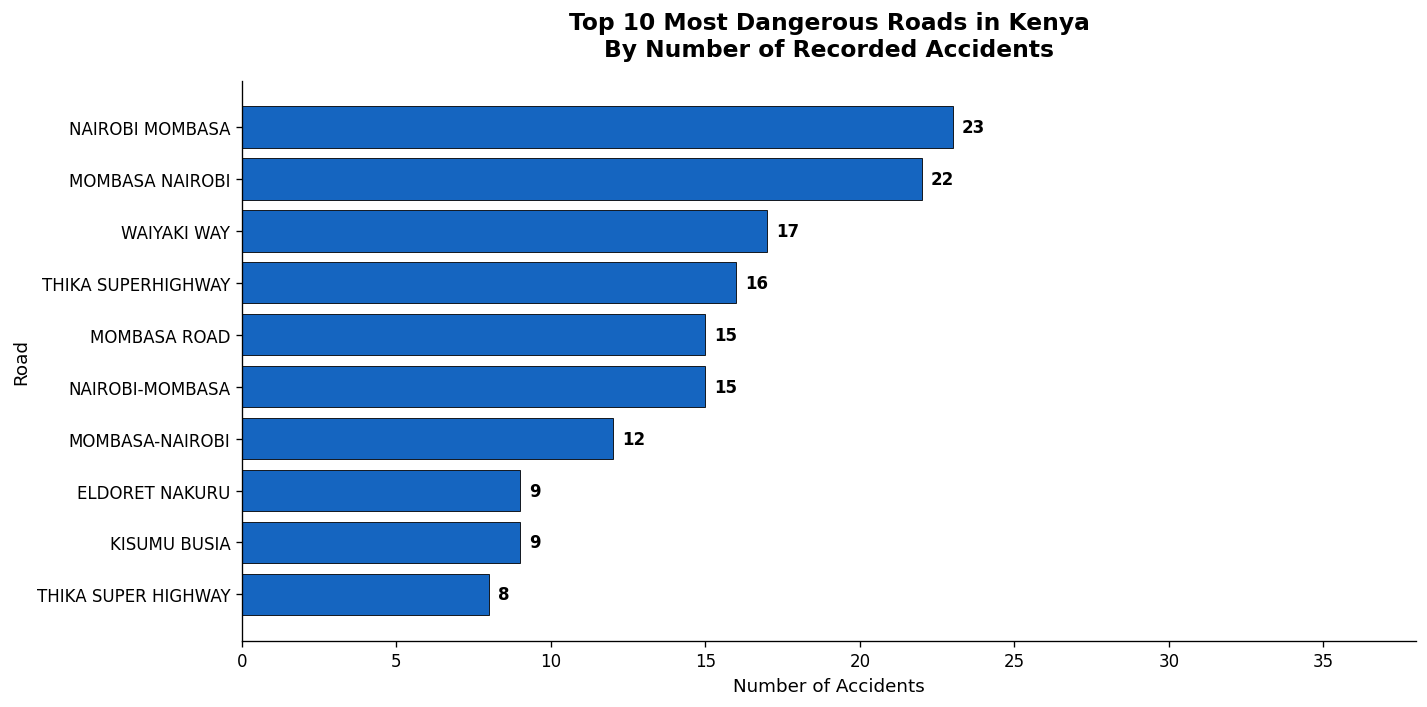

Chart 5 saved


In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

road_counts = (
    df['road']
    .value_counts()
    .dropna()
    .head(10)
)

bars = ax.barh(
    road_counts.index[::-1],
    road_counts.values[::-1],
    color='#1565C0', edgecolor='black', linewidth=0.5
)
for bar, val in zip(bars, road_counts.values[::-1]):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height()/2,
            str(val), va='center',
            fontsize=10, fontweight='bold')

ax.set_title('Top 10 Most Dangerous Roads in Kenya\n'
             'By Number of Recorded Accidents',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Accidents', fontsize=11)
ax.set_ylabel('Road', fontsize=11)
ax.set_xlim(0, road_counts.max() + 15)

plt.tight_layout()
plt.savefig(os.path.join(VISUALS, 'chart5_dangerous_roads.png'),
            bbox_inches='tight')
plt.show()
print("Chart 5 saved")

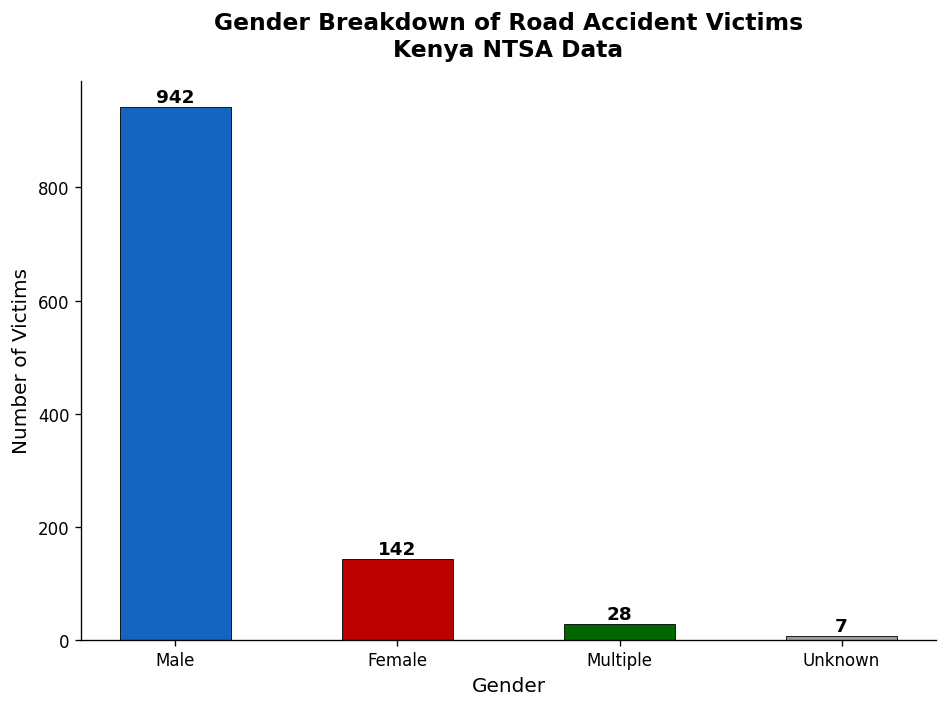

Chart 6 saved


In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

gender_counts = df['gender_clean'].value_counts()

colors = ['#1565C0','#BB0000','#006600','#9E9E9E']
bars = ax.bar(
    gender_counts.index,
    gender_counts.values,
    color=colors[:len(gender_counts)],
    edgecolor='black', linewidth=0.5,
    width=0.5
)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2,
            str(int(bar.get_height())),
            ha='center', va='bottom',
            fontsize=11, fontweight='bold')

ax.set_title('Gender Breakdown of Road Accident Victims\n'
             'Kenya NTSA Data',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Gender', fontsize=12)
ax.set_ylabel('Number of Victims', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(VISUALS, 'chart6_gender.png'),
            bbox_inches='tight')
plt.show()
print("Chart 6 saved")

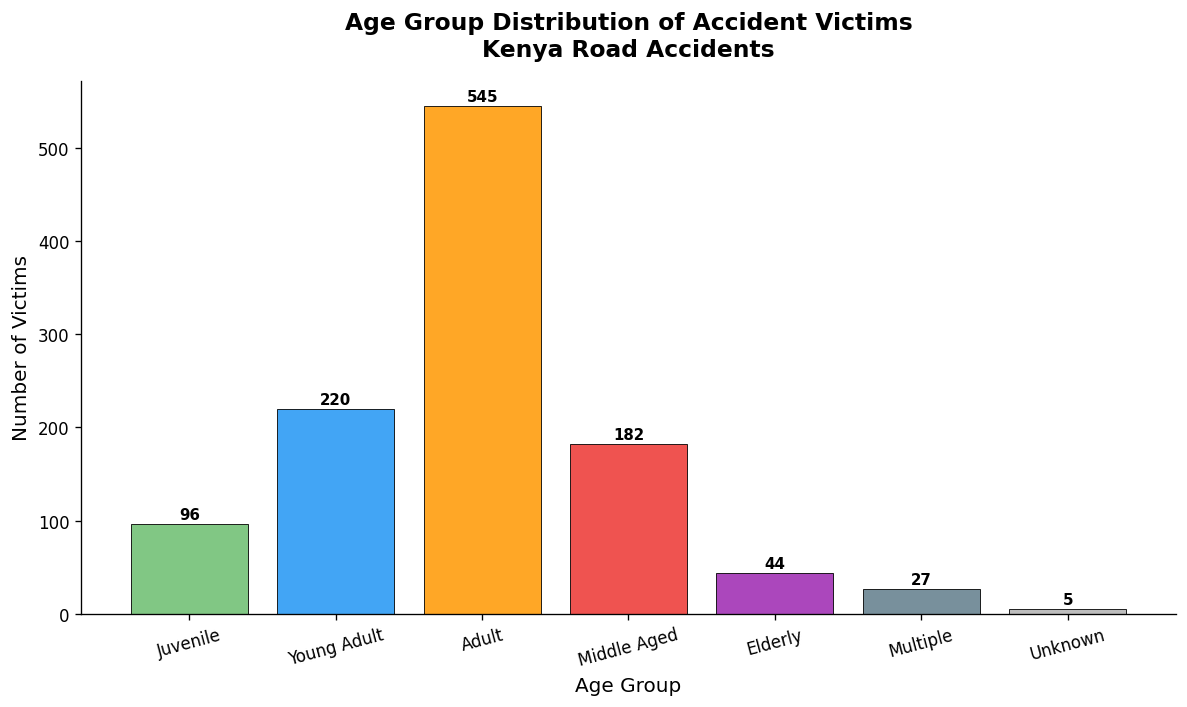

Chart 7 saved


In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

age_order  = ['Juvenile', 'Young Adult', 'Adult',
              'Middle Aged', 'Elderly', 'Multiple', 'Unknown']
age_counts = df['age_group'].value_counts()
age_counts = age_counts.reindex(
    [a for a in age_order if a in age_counts.index]
)

colors = ['#81C784','#42A5F5','#FFA726',
          '#EF5350','#AB47BC','#78909C','#BDBDBD']
bars = ax.bar(
    age_counts.index,
    age_counts.values,
    color=colors[:len(age_counts)],
    edgecolor='black', linewidth=0.5
)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2,
            str(int(bar.get_height())),
            ha='center', va='bottom',
            fontsize=9, fontweight='bold')

ax.set_title('Age Group Distribution of Accident Victims\n'
             'Kenya Road Accidents',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Number of Victims', fontsize=12)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(os.path.join(VISUALS, 'chart7_age_groups.png'),
            bbox_inches='tight')
plt.show()
print("Chart 7 saved")

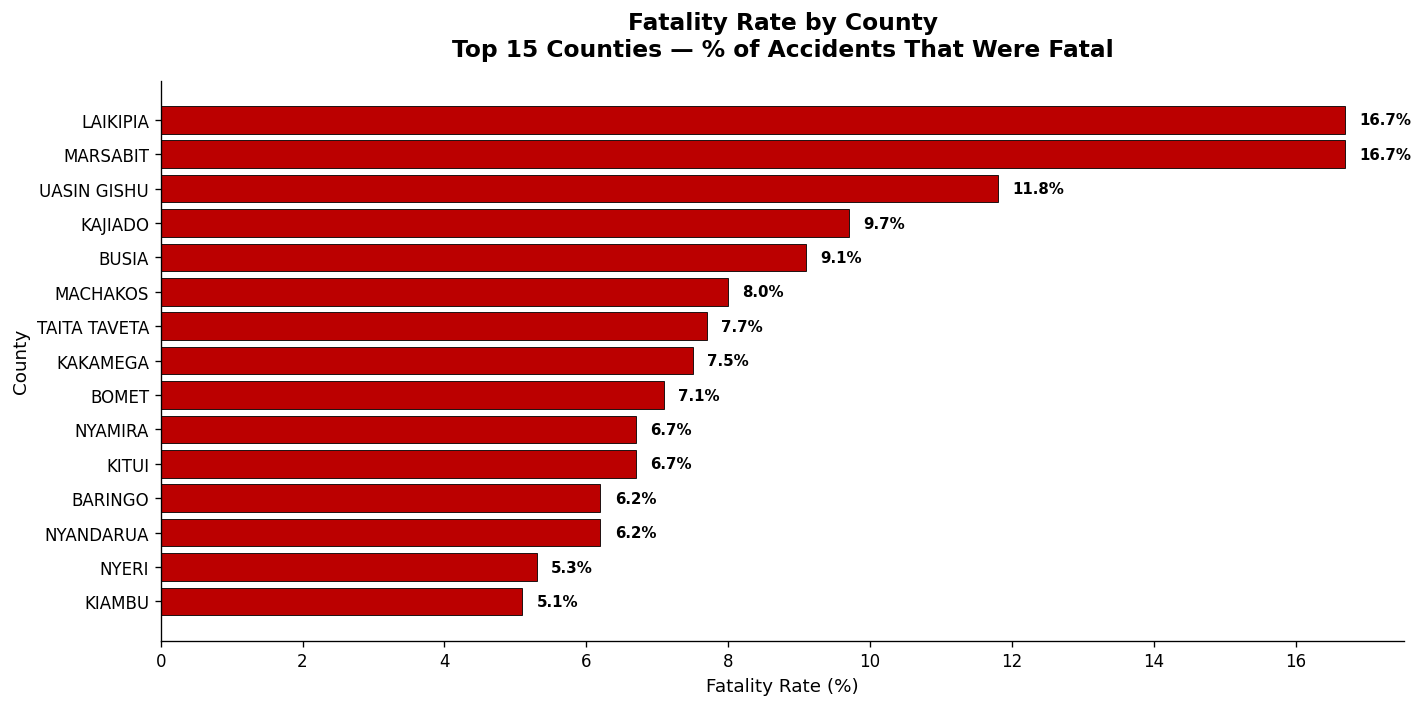

Chart 8 saved


In [12]:
fig, ax = plt.subplots(figsize=(12, 6))

fatality_by_county = (
    df.groupby('county')['is_fatal']
    .agg(['sum', 'count'])
    .reset_index()
)
fatality_by_county.columns = [
    'county', 'fatal', 'total'
]
fatality_by_county['fatality_rate'] = (
    fatality_by_county['fatal'] /
    fatality_by_county['total'] * 100
).round(1)

# Only counties with at least 5 accidents
fatality_by_county = (
    fatality_by_county[fatality_by_county['total'] >= 5]
    .sort_values('fatality_rate', ascending=False)
    .head(15)
)

bars = ax.barh(
    fatality_by_county['county'][::-1],
    fatality_by_county['fatality_rate'][::-1],
    color='#BB0000', edgecolor='black', linewidth=0.5
)
for bar, val in zip(
    bars, fatality_by_county['fatality_rate'][::-1]
):
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center',
            fontsize=9, fontweight='bold')

ax.set_title('Fatality Rate by County\n'
             'Top 15 Counties — % of Accidents That Were Fatal',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Fatality Rate (%)', fontsize=11)
ax.set_ylabel('County', fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(VISUALS, 'chart8_fatality_rate.png'),
            bbox_inches='tight')
plt.show()
print("Chart 8 saved")

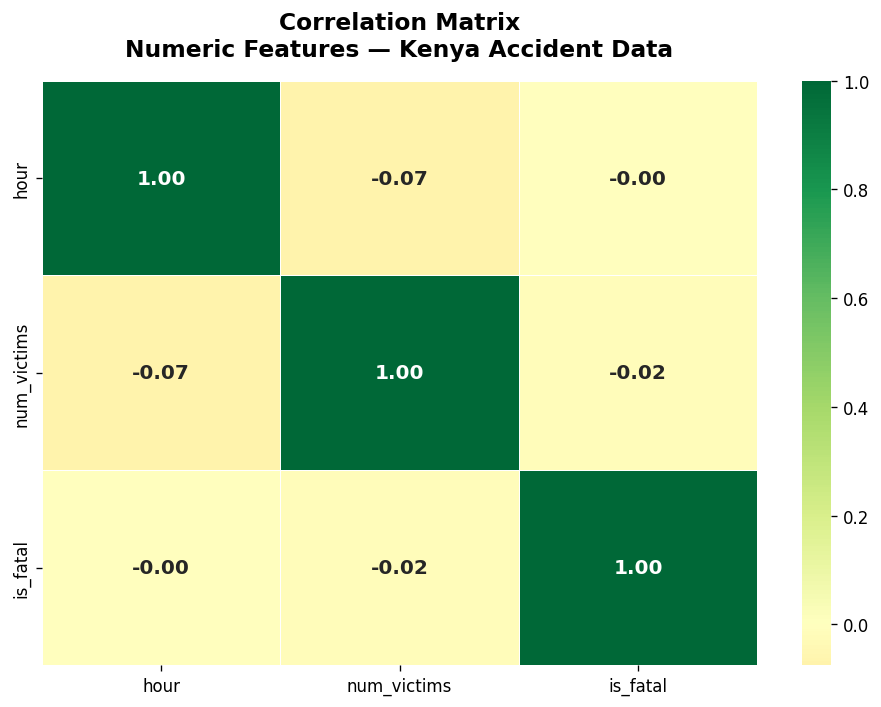

Chart 9 saved


In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

numeric_cols = [
    'hour', 'num_victims', 'is_fatal'
]
corr_matrix = df[numeric_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 12, 'weight': 'bold'}
)

ax.set_title('Correlation Matrix\n'
             'Numeric Features — Kenya Accident Data',
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(os.path.join(VISUALS, 'chart9_correlation.png'),
            bbox_inches='tight')
plt.show()
print("Chart 9 saved")

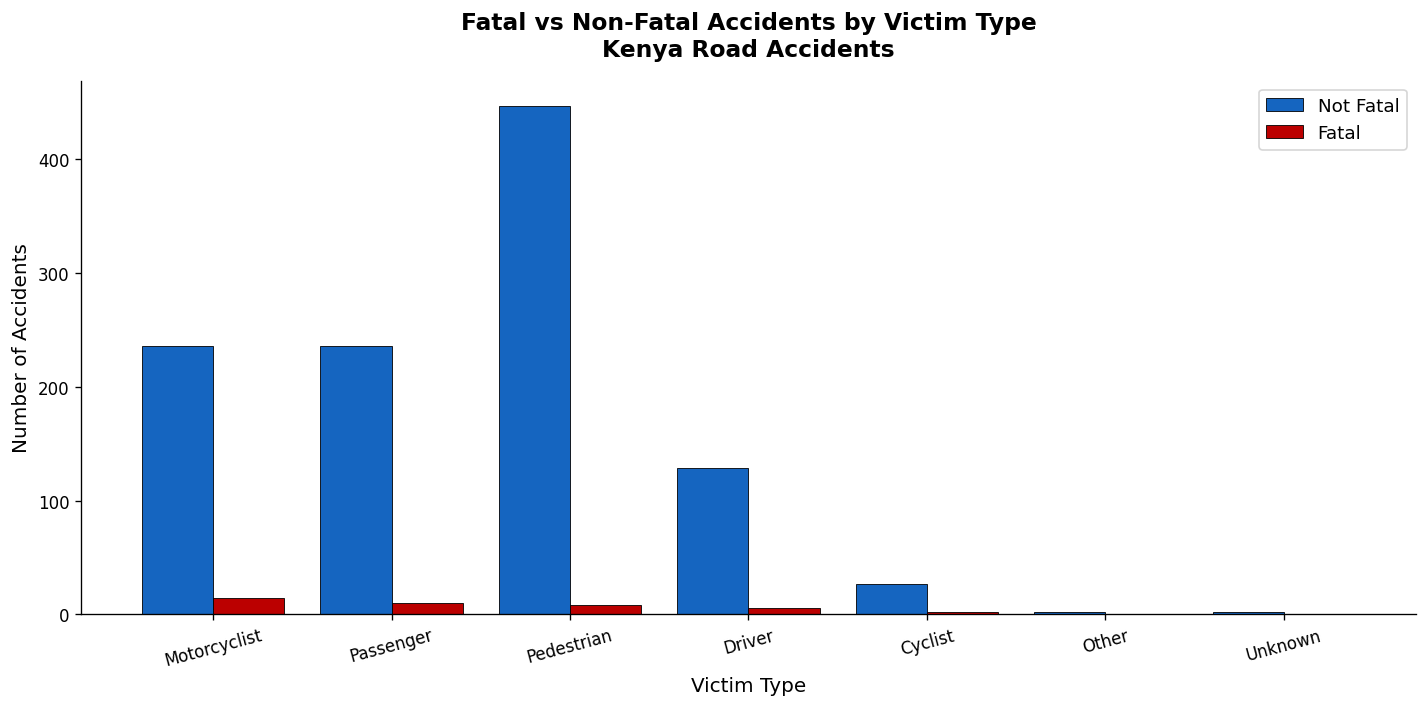

Chart 10 saved


In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

fatal_by_victim = df.groupby(
    ['victim_category', 'is_fatal']
).size().unstack(fill_value=0)

fatal_by_victim.columns = ['Not Fatal', 'Fatal']
fatal_by_victim = fatal_by_victim.sort_values(
    'Fatal', ascending=False
)

x     = range(len(fatal_by_victim))
width = 0.4

bars1 = ax.bar(
    [i - width/2 for i in x],
    fatal_by_victim['Not Fatal'],
    width, label='Not Fatal',
    color='#1565C0', edgecolor='black', linewidth=0.5
)
bars2 = ax.bar(
    [i + width/2 for i in x],
    fatal_by_victim['Fatal'],
    width, label='Fatal',
    color='#BB0000', edgecolor='black', linewidth=0.5
)

ax.set_xticks(list(x))
ax.set_xticklabels(fatal_by_victim.index, rotation=15)
ax.set_title('Fatal vs Non-Fatal Accidents by Victim Type\n'
             'Kenya Road Accidents',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Victim Type', fontsize=12)
ax.set_ylabel('Number of Accidents', fontsize=12)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(VISUALS, 'chart10_fatal_by_victim.png'),
            bbox_inches='tight')
plt.show()
print("Chart 10 saved")

In [15]:
print("="*55)
print("EDA COMPLETE — SUMMARY OF FINDINGS")
print("="*55)
print(f"Total charts produced : 10")
print(f"Charts saved to       : {VISUALS}")
print()
print("Key Findings:")
print(f"  Most accidents in   : "
      f"{df['county'].value_counts().index[0]}")
print(f"  Most dangerous road : "
      f"{df['road'].value_counts().index[0]}")
print(f"  Most affected victim: "
      f"{df['victim_category'].value_counts().index[0]}")
print(f"  Peak accident time  : "
      f"{df['time_of_day'].value_counts().index[0]}")
print(f"  Overall fatal rate  : "
      f"{df['is_fatal'].mean()*100:.1f}%")
print()
print("All 10 charts saved to visuals/ folder")
print("Ready for Machine Learning — Notebook 4")

EDA COMPLETE — SUMMARY OF FINDINGS
Total charts produced : 10
Charts saved to       : C:\Users\Administrator\Desktop\kenya_road_safety_project\visuals

Key Findings:
  Most accidents in   : NAIROBI
  Most dangerous road : NAIROBI MOMBASA
  Most affected victim: Pedestrian
  Peak accident time  : Evening
  Overall fatal rate  : 3.6%

All 10 charts saved to visuals/ folder
Ready for Machine Learning — Notebook 4
